In [7]:
!pip install awswrangler
import awswrangler as wr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import boto3
from google.colab import userdata


# 1. AWS Access Key ID
aws_access_key_id = userdata.get('aws_access_key_id')

# 2. Secret Access Key e Session Token
aws_secret_access_key = userdata.get('aws_secret_access_key')

aws_session_token = userdata.get('aws_session_token')

# 3. Configurar credenciais AWS
boto3.setup_default_session(
    region_name="us-east-1",
    aws_access_key_id=aws_access_key_id,
    aws_secret_access_key=aws_secret_access_key,
    aws_session_token=aws_session_token
)
print("Sessão AWS autenticada com sucesso!")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.3/396.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 8.2 MB/s eta 0:00:00
Sessão AWS autenticada com sucesso!


Gerando Gráfico 1: Modelos de Trabalho...


/usr/local/lib/python3.13/dist-packages/awswrangler/athena/_utils.py:839: UserWarning: No `s3_output` was provided and the workgroup has no ResultConfiguration set. Falling back to the default bucket `aws-athena-query-results-{account}-{region}`. Because S3 bucket names are global, relying on this predictable default is discouraged: pass an explicit `s3_output`, or configure a workgroup with EnforceWorkGroupConfiguration=true and a ResultConfiguration.
  s3_output = _get_s3_output(s3_output=s3_output, wg_config=wg_config, boto3_session=boto3_session)
/tmp/ipykernel_580/1209998642.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


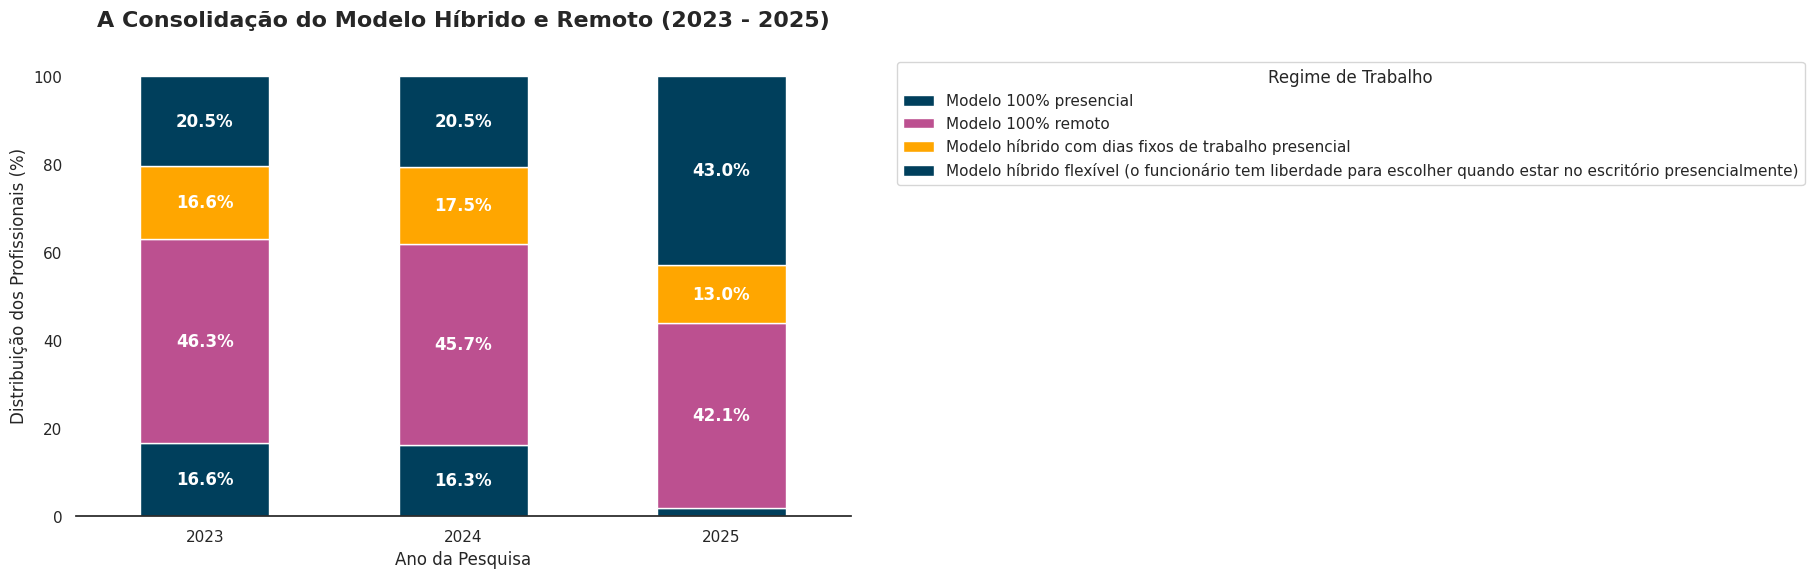

Gerando Gráfico 2: Remuneração e IA...


/usr/local/lib/python3.13/dist-packages/awswrangler/athena/_utils.py:839: UserWarning: No `s3_output` was provided and the workgroup has no ResultConfiguration set. Falling back to the default bucket `aws-athena-query-results-{account}-{region}`. Because S3 bucket names are global, relying on this predictable default is discouraged: pass an explicit `s3_output`, or configure a workgroup with EnforceWorkGroupConfiguration=true and a ResultConfiguration.
  s3_output = _get_s3_output(s3_output=s3_output, wg_config=wg_config, boto3_session=boto3_session)


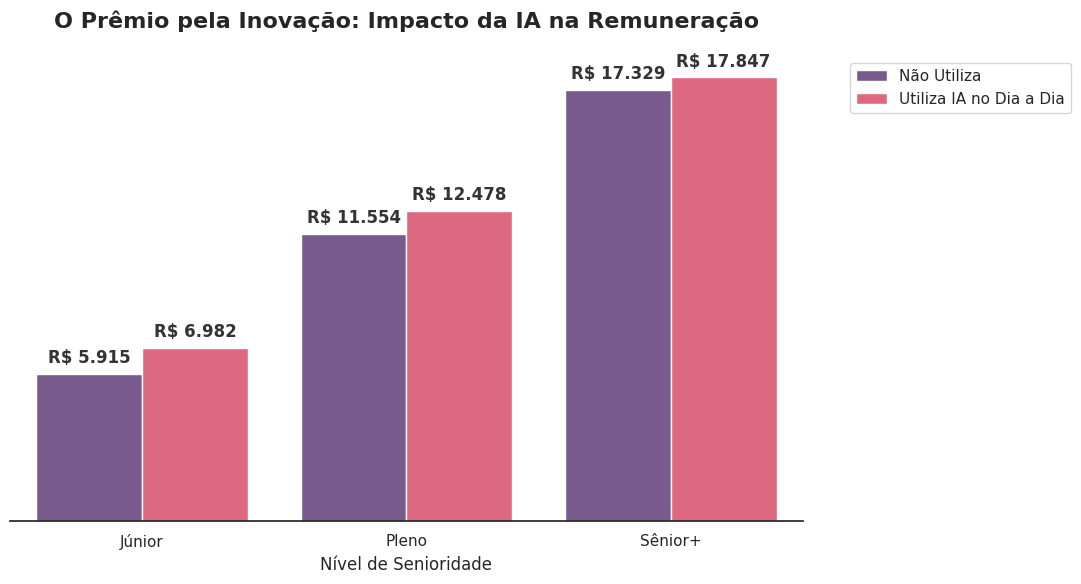

Gerando Gráfico 3: Diversidade de Gênero...


/usr/local/lib/python3.13/dist-packages/awswrangler/athena/_utils.py:839: UserWarning: No `s3_output` was provided and the workgroup has no ResultConfiguration set. Falling back to the default bucket `aws-athena-query-results-{account}-{region}`. Because S3 bucket names are global, relying on this predictable default is discouraged: pass an explicit `s3_output`, or configure a workgroup with EnforceWorkGroupConfiguration=true and a ResultConfiguration.
  s3_output = _get_s3_output(s3_output=s3_output, wg_config=wg_config, boto3_session=boto3_session)


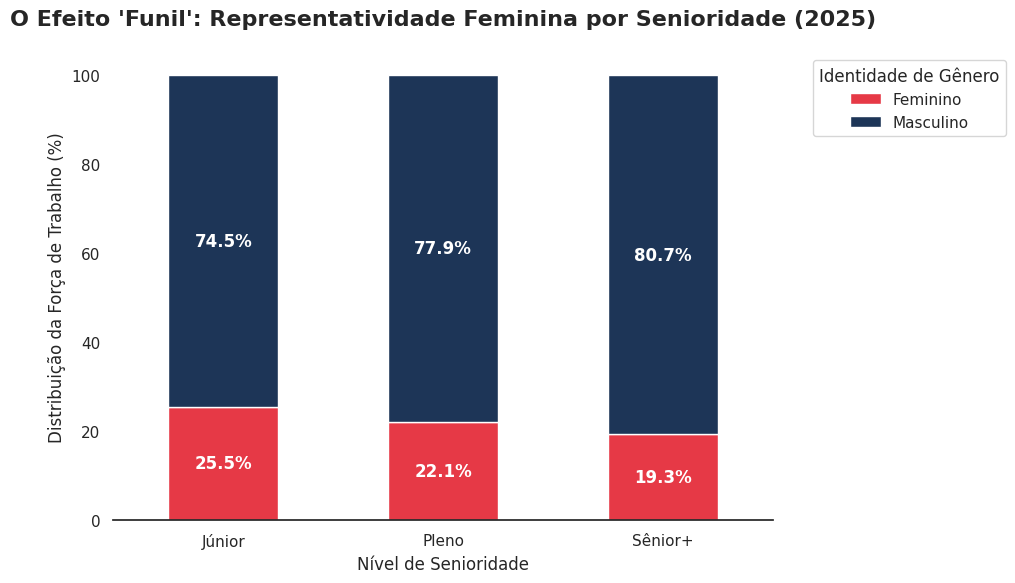

In [11]:
sns.set_theme(style="white")
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'font.size': 12,
    'axes.titleweight': 'bold',
    'axes.titlepad': 20
})

# GRÁFICO 1: EVOLUÇÃO DOS MODELOS DE TRABALHO

print("Gerando Gráfico 1: Modelos de Trabalho...")
query_modelo = """
    SELECT ano_pesquisa, modelo_trabalho, COUNT(*) as total
    FROM default.gold_remuneracao_ia
    WHERE modelo_trabalho IS NOT NULL AND modelo_trabalho != 'Outros / Não informado'
    GROUP BY ano_pesquisa, modelo_trabalho
"""
df_modelo = wr.athena.read_sql_query(sql=query_modelo, database="default")


df_pivot = df_modelo.pivot(index='ano_pesquisa', columns='modelo_trabalho', values='total').fillna(0)
df_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100


cores_trabalho = ['#003f5c', '#bc5090', '#ffa600']
ax1 = df_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=cores_trabalho)

plt.title("A Consolidação do Modelo Híbrido e Remoto (2023 - 2025)", fontsize=16)
plt.ylabel("Distribuição dos Profissionais (%)")
plt.xlabel("Ano da Pesquisa")
plt.xticks(rotation=0)
plt.legend(title="Regime de Trabalho", bbox_to_anchor=(1.05, 1), loc='upper left')


for c in ax1.containers:

    labels = [f'{v.get_height():.1f}%' if v.get_height() > 5 else '' for v in c]
    ax1.bar_label(c, labels=labels, label_type='center', color='white', weight='bold')

plt.tight_layout()
plt.savefig("grafico_1_modelos_trabalho.png", dpi=300, transparent=True)
plt.show()


# GRÁFICO 2: IA E REMUNERAÇÃO

print("Gerando Gráfico 2: Remuneração e IA...")
query_ia = """
    SELECT senioridade, usa_ia, AVG(salario_numerico) as salario_medio
    FROM default.gold_remuneracao_ia
    WHERE senioridade IS NOT NULL AND salario_numerico IS NOT NULL
    GROUP BY senioridade, usa_ia
"""
df_ia = wr.athena.read_sql_query(sql=query_ia, database="default")


df_ia['Usa IA'] = df_ia['usa_ia'].apply(lambda x: 'Utiliza IA no Dia a Dia' if x == 1 else 'Não Utiliza')


ordem = ['Júnior', 'Pleno', 'Sênior+']

plt.figure(figsize=(11, 6))
ax2 = sns.barplot(data=df_ia, x='senioridade', y='salario_medio', hue='Usa IA',
                  order=ordem, palette=['#7a5195', '#ef5675'])

plt.title("O Prêmio pela Inovação: Impacto da IA na Remuneração", fontsize=16)
plt.ylabel("")
plt.xlabel("Nível de Senioridade")
plt.yticks([])


for c in ax2.containers:
    labels = [f'R$ {int(v.get_height()):,}'.replace(',', '.') for v in c]
    ax2.bar_label(c, labels=labels, label_type='edge', padding=5, weight='bold', color='#333333')

plt.legend(title="", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("grafico_2_remuneracao_ia.png", dpi=300, transparent=True)
plt.show()


# GRÁFICO 3: DIVERSIDADE

print("Gerando Gráfico 3: Diversidade de Gênero...")
query_div = """
    SELECT senioridade, genero, SUM(volume) as total
    FROM default.gold_diversidade
    WHERE ano_pesquisa = 2025
      AND genero IN ('Masculino', 'Feminino')
      AND senioridade IS NOT NULL
    GROUP BY senioridade, genero
"""
df_div = wr.athena.read_sql_query(sql=query_div, database="default")

df_pivot_div = df_div.pivot(index='senioridade', columns='genero', values='total').fillna(0)
df_pivot_div = df_pivot_div.reindex(ordem)
df_pct_div = df_pivot_div.div(df_pivot_div.sum(axis=1), axis=0) * 100

ax3 = df_pct_div.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#e63946', '#1d3557'])

plt.title("O Efeito 'Funil': Representatividade Feminina por Senioridade (2025)", fontsize=16)
plt.ylabel("Distribuição da Força de Trabalho (%)")
plt.xlabel("Nível de Senioridade")
plt.xticks(rotation=0)
plt.legend(title="Identidade de Gênero", bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax3.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 5 else '' for v in c]
    ax3.bar_label(c, labels=labels, label_type='center', color='white', weight='bold')

plt.tight_layout()
plt.savefig("grafico_3_diversidade_genero.png", dpi=300, transparent=True)
plt.show()